# Decision Tree Basics
---

## 1. Measuring Purity (Gini vs. Entropy)
### **A. Gini Impurity (CART)**
Measures the probability of a random element being misclassified.
* **Range:** 0 (Perfectly Pure) to 0.5 (Maximum Impurity)
* **Formula:** $$Gini = 1 - \sum_{i=1}^{n} p_i^2$$
>
#### **Example**
* Dataset with 7 Apples, 3 Oranges
$$Gini = 1 - \sum p_i^2$$
$$Gini = 1 - (0.7^2 + 0.3^2)$$
$$Gini = 1 - (0.49 + 0.09) = \mathbf{0.42}$$

### **B. Entropy (ID3)**
Measures the "disorder" or uncertainty in the data.
* **Range:** 0 (Perfect Order) to 1 (Chaos).
* **Formula:** $$H(S) = -\sum_{i=1}^{n} p_i \log_2(p_i)$$
*A score of **0** means the node is perfectly pure (all items are the same class).*
#### **Example**
* Using the same dataset as above to calculate the entroy
$$H(S) = -(0.7 \log_2 0.7 + 0.3 \log_2 0.3)$$
$$H(S) = -(-0.36 - 0.52) = \mathbf{0.88}$$

--- 
## 2. Information Gain
Information Gain (IG) is a metric used to determine the quality of a split (higher is better).

**The Goal:** The algorithm calculates IG for every possible split and chooses the one with the **highest value**.

$$IG(S, A) = \text{Entropy(Parent)} - \sum (\text{Weighted Entropy of Children}) $$

---

## 3. Pruning
A decision tree left to its own devices will grow until it has perfectly memorized the training data (including the noise). This is called **Overfitting**.

### **Two Ways to Prune:**
1. **Pre-Pruning (Early Stopping):** * Stop the tree before it gets too complex.
   * Limits: `max_depth`, `min_samples_leaf`, or `max_leaf_nodes`.
2. **Post-Pruning (Cost-Complexity Pruning):**
   * Let the tree grow fully.
   * "Trim" back the branches that add the least predictive value.

---

## 4. Summary & Comparison
* **Gini** is faster to calculate (no logs); **Entropy** is more mathematically intensive but can produce slightly more balanced trees.
* **Information Gain** is the metric used to pick the "winning" feature for a split.
* **Pruning** is essential to ensure the model works on new, unseen data.

Decision Tree

- Machine Learning Modell → Entscheidungen als Baumstruktur
- Daten werden durch Fragen schrittweise aufgeteilt
- Ergebnis: Vorhersage am Ende des Baums
- Lernt Regeln aus Daten

Einsatzbereiche:

Klassifikation
→ z.B. Spam vs. kein Spam

Regression
→ z.B. Hauspreis vorhersagen


Aufbau: 

- Root (Wurzel):
Startpunkt
erste Entscheidung / Frage

- Decision Nodes
weitere Fragen
teilen Daten in kleinere Gruppen

- Leaf Nodes
Ende des Baums
finale Vorhersage


Vor- und Nachteile:
- Vorteile
einfach verständlich & interpretierbar
keine starken Annahmen über Daten
funktioniert mit numerischen Daten und kategorischen Daten

- Nachteile
Overfitting: lernt Trainingsdaten zu genau
instabil → kleine Datenänderung → anderer Baum


Vergleich: Lineare Regression

- Decision Tree
kann nichtlineare Zusammenhänge modellieren

- Lineare Regression:
nimmt lineare Beziehung an
oft stabiler & einfacher

-------

BEISPIEL
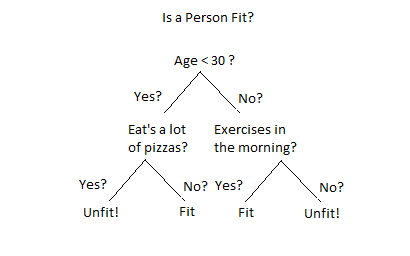

**Calculate Gini Impurity [(source)](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity):**
J... Labels
p... Probability of randomly selecting label
$$Gini = 1 - \sum_{i=1}^{J} p^2_i$$


In [161]:
import pandas as pd
import numpy as np

In [162]:
X_train = pd.DataFrame(
    [
        ["Green", 3],
        ["Yellow", 3],
        ["Red", 1],
        ["Red", 1],
        ["Yellow", 3],
    ],
    columns=["color", "diameter"],
)

y_train = pd.DataFrame(["Apple", "Apple", "Grape", "Grape", "Lemon"])

In [163]:
class Decision:
    def __init__(self, df, column_index, value):
        self.column_index = column_index
        self.column_name = df.columns[column_index]
        self.value = value

    def match(self, example):
        val = example[self.column_name]

        if isinstance(self.value, (int, float, np.number)):  # Numeric
            return val >= self.value
        return val == self.value  # Other

    def __repr__(self):
        condition = ">=" if isinstance(self.value, (int, float, np.number)) else "=="
        return f"{self.column_name} {condition} {self.value}?"

In [164]:
d = Decision(X_train, 0, "Yellow")  # Is column 0 (color) Yellow?

print('["Green", 3, "Apple"]: ', d.match(X_train.iloc[0]))
print('["Yellow", 3, "Apple"]: ', d.match(X_train.iloc[1]))

["Green", 3, "Apple"]:  False
["Yellow", 3, "Apple"]:  True


In [165]:
def partition(X, y, question):
    mask = X.apply(lambda row: question.match(row), axis=1)
    return X[mask], y[mask], X[~mask], y[~mask]


# Usage:
X_t, _, _, _ = partition(X_train, y_train, d)
print("Decision: ", d)
X_t

Decision:  color == Yellow?


,color,diameter
1,Yellow,3
4,Yellow,3


In [166]:
def gini(y):
    # automatically calculates probablities for each label
    probs = y.value_counts(normalize=True)
    return 1 - (probs**2).sum()


# 0% Chance of misclassification
print('Gini for ["Apple", "Apple"]:', gini(pd.Series(["Apple", "Apple"])))

# 50% Chance of misclassification
print('Gini for ["Apple", "Grape"]:', gini(pd.Series(["Apple", "Grape"])))

# 66.7% Chance of misclassification a random example from the dataset
print(
    'Gini for ["Apple", "Grape", "Peach"]:',
    gini(pd.Series(["Apple", "Grape", "Peach"])),
)

Gini for ["Apple", "Apple"]: 0.0
Gini for ["Apple", "Grape"]: 0.5
Gini for ["Apple", "Grape", "Peach"]: 0.6666666666666667


Information gain (simplified for Binary split)

$$IG = Gini(y\_parent) - \frac{|y\_left|}{|y\_total|} * Gini(y\_left) - \frac{|y\_right|}{|y\_total|} * Gini(y\_right)$$


In [167]:
def information_gain(y_left, y_right, current_impurity):
    n_left = len(y_left)
    n_right = len(y_right)
    n_total = n_left + n_right

    return (
        current_impurity  # Gini(y_parent)
        - (n_left / n_total) * gini(y_left)
        - (n_right / n_total) * gini(y_right)
    )

In [168]:
current_impurity = gini(y_train)

X_t_green, y_t_green, X_f_green, y_f_green = partition(
    X_train, y_train, Decision(X_train, 0, "Green")
)

ig_green = information_gain(
    y_left=y_t_green,
    y_right=y_f_green,
    current_impurity=current_impurity,
)

X_t_red, y_t_red, X_f_red, y_f_red = partition(
    X_train, y_train, Decision(X_train, 0, "Red")
)

ig_red = information_gain(
    y_left=y_t_red, y_right=y_f_red, current_impurity=current_impurity
)

print(f"Information Gain for Green: {round(ig_green, 3)}")
print(f"Information Gain for Red: {round(ig_red, 3)}")

Information Gain for Green: 0.14
Information Gain for Red: 0.373


In [169]:
def find_best_split(X, y):
    best_gain = 0
    best_split = None
    current_uncertainty = gini(y)  # ... with respect to the label

    # Iterate over features
    for col_idx in range(len(X.columns)):
        # Try split for all values in column (e.g. Red, Yellow...)
        values = X.iloc[:, col_idx].unique()

        for val in values:
            decision = Decision(X, col_idx, val)
            _, y_t, _, y_f = partition(X, y, decision)

            if len(y_t) == 0 or len(y_f) == 0:
                continue

            # information gain from this split, with respect to the label column (e.g fruit)
            gain = information_gain(y_t, y_f, current_uncertainty)

            # Keep Track of best gain so far
            if gain >= best_gain:
                best_gain, best_split = gain, decision

    return best_gain, best_split

In [170]:
find_best_split(X_train, y_train)

(np.float64(0.37333333333333324), diameter >= 3?)

In [171]:
class Leaf:
    def __init__(self, y):
        self.predictions = y


class Decision_Node:
    def __init__(self, question, true_branch, false_branch):
        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch

In [172]:
def build_tree(X, y, max_depth=3, current_depth=0):
    gain, question = find_best_split(X, y)

    # No more decision to be performed, dead-end
    if gain == 0 or current_depth >= max_depth:
        return Leaf(y)

    # Ask best question
    X_t, y_t, X_f, y_f = partition(X, y, question)

    # Recursively building Tree
    true_branch = build_tree(X_t, y_t, max_depth, current_depth + 1)
    false_branch = build_tree(X_f, y_f, max_depth, current_depth + 1)

    return Decision_Node(question, true_branch=true_branch, false_branch=false_branch)

In [173]:
def print_tree(node, spacing=""):
    if isinstance(node, Leaf):
        preds = node.predictions.iloc[:, 0].to_dict()
        summary = {k: v for k, v in preds.items()}
        print(spacing + "└── Prediction: " + str(summary))
        return

    print(spacing + "(" + str(node.question) + ")")
    print(spacing + "├── True:")
    print_tree(node.true_branch, spacing + "│   ")
    print(spacing + "└── False:")
    print_tree(node.false_branch, spacing + "    ")

In [174]:
tree = build_tree(X_train, y_train)
print_tree(tree)

(diameter >= 3?)
├── True:
│   (color == Yellow?)
│   ├── True:
│   │   └── Prediction: {1: 'Apple', 4: 'Lemon'}
│   └── False:
│       └── Prediction: {0: 'Apple'}
└── False:
    └── Prediction: {2: 'Grape', 3: 'Grape'}


In [175]:
def predict(row, node):
    # base-case, leaf can return its predictions
    if isinstance(node, Leaf):
        return set(node.predictions.iloc[:, 0])

    # recurse
    if node.question.match(row):
        return predict(row, node.true_branch)
    else:
        return predict(row, node.false_branch)

In [176]:
X_test = pd.DataFrame(
    [
        ["Red", 1],  # Easy example: Grape
        ["Yellow", 3],  # Could either be Apple or Lemon
        ["Green", 5],  # How does it handle new Values - probably Apple?
        ["Blabla", -2],  # Faulty data
    ],
    columns=["color", "diameter"],
)

# Grape
print(predict(X_test.iloc[0], tree))

# Returns both Apple and lemon => we need to decide ourselves (e.g. random, mode)
print(predict(X_test.iloc[1], tree))

# Apple
print(predict(X_test.iloc[2], tree))

# Whatever this is
print(predict(X_test.iloc[3], tree))

{'Grape'}
{'Lemon', 'Apple'}
{'Apple'}
{'Grape'}


In [190]:
X_train = pd.DataFrame(
    [
        [175.2, 30, "Male"],
        [172.3, 30, "Male"],
        [162.5, 57, "Female"],
        [150.0, 14, "Male"],
        [101.6, 4, "Female"],
        [88.9, 2, "Male"],
        [188.0, 25, "Male"],
        [155.4, 65, "Female"],
    ],
    columns=["height", "age", "gender"],
)

# y: Continuous weight in kilograms
y_train = pd.DataFrame(
    [74.5, 94.3, 68.2, 45.0, 16.5, 12.8, 92.1, 61.4], columns=["weight"]
)

In [178]:
# hacky solution to change uncertainty measurement
# replace gini with variance
def gini(y):
    if len(y) == 0:  # Avoid degrees of freedom warning
        return 0
    return np.var(y.iloc[:, 0])


def predict(row, node):
    if isinstance(node, Leaf):
        return node.predictions.iloc[
            :, 0
        ].mean()  # Calculate mean instead of returning predictions

    # recurse
    if node.question.match(row):
        return predict(row, node.true_branch)
    else:
        return predict(row, node.false_branch)

In [179]:
regression_tree = build_tree(X_train, y_train, max_depth=3)
print_tree(regression_tree)

(age >= 25?)
├── True:
│   (gender == Female?)
│   ├── True:
│   │   (age >= 65?)
│   │   ├── True:
│   │   │   └── Prediction: {7: 61.4}
│   │   └── False:
│   │       └── Prediction: {2: 68.2}
│   └── False:
│       (height >= 175.2?)
│       ├── True:
│       │   └── Prediction: {0: 74.5, 6: 92.1}
│       └── False:
│           └── Prediction: {1: 94.3}
└── False:
    (age >= 14?)
    ├── True:
    │   └── Prediction: {3: 45.0}
    └── False:
        (gender == Male?)
        ├── True:
        │   └── Prediction: {5: 12.8}
        └── False:
            └── Prediction: {4: 16.5}


In [187]:
X_test = pd.DataFrame([[185.2, 32, "Male"]], columns=["height", "age", "gender"])
predict(X_test.iloc[0], regression_tree)

np.float64(83.3)

Sources:

- [Video](https://www.youtube.com/watch?v=LDRbO9a6XPU)
- [Wikipedia](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity)
- [Decision tree - geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/)
- [Sklearn](https://scikit-learn.org/stable/modules/tree.html)
